In [84]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Scanpy settings for speed
sc.settings.verbosity = 3
sc.set_figure_params(dpi=80, color_map='viridis', format='png') # png is faster than svg/pdf for notebooks

In [108]:
# --- 1. PATHS ---
MODE = 'dp'  # 'slide' or 'dp' 
DATASET_NAME = 'pauli_2' 

if MODE == 'slide':
    BASE_DIR = "/storage/research/igmp_slide_workspace/GRP Zlobec/Sergio/MPI/Data"
elif MODE == 'dp':
    BASE_DIR = "/storage/research/igmp_dp_workspace/sergio_vazquez/MPI/Data/"

INPUT_FILE = os.path.join(BASE_DIR, "Processed_Datasets", f"{DATASET_NAME}_clean_with_velocity.h5ad")
OUTPUT_FILE = os.path.join(BASE_DIR, "Processed_Datasets", f"{DATASET_NAME}_clean_with_velocity_FINAL.h5ad")

adata = sc.read_h5ad(INPUT_FILE)

In [109]:
# --- QC Configuration ---
mt_gene_prefix = "MT-"

# --- QC Filtering Thresholds ---
min_genes_per_cell = 500
max_genes_per_cell = 3000
min_counts_per_cell = 600
max_counts_per_cell = 8000
max_mt_pct = 15
min_cells_per_gene = 3

In [110]:
print("--- Calculating QC Metrics ---")

# 1. Identify mitochondrial genes
adata.var['mt'] = adata.var_names.str.startswith(mt_gene_prefix)
print(f"Found {adata.var['mt'].sum()} mitochondrial genes using prefix '{mt_gene_prefix}'.")
if adata.var['mt'].sum() == 0:
    print(f"Warning: No mitochondrial genes found with prefix '{mt_gene_prefix}'. "
          "Check the prefix for your species (e.g., 'mt-' for mouse). "
          "Skipping mitochondrial percentage calculation/filtering if none found.")

# 2. Calculate QC metrics and store them in adata.obs
sc.pp.calculate_qc_metrics(
    adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True
)

print("Calculated QC metrics added to adata_full.obs:")
print(adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].head())

print("--- Applying Cell QC Filters ---")
print(f"Initial cell count: {adata.n_obs}")

# Create boolean flags for each QC criterion
adata.obs['passes_min_genes'] = adata.obs['n_genes_by_counts'] >= min_genes_per_cell
adata.obs['passes_max_genes'] = adata.obs['n_genes_by_counts'] <= max_genes_per_cell
adata.obs['passes_min_counts'] = adata.obs['total_counts'] >= min_counts_per_cell
adata.obs['passes_max_counts'] = adata.obs['total_counts'] <= max_counts_per_cell
adata.obs['passes_max_mt'] = adata.obs['pct_counts_mt'] <= max_mt_pct

# Combine flags - a cell must pass all criteria
passes_all_cell_qc = np.all(adata.obs[['passes_min_genes', 'passes_max_genes', 'passes_min_counts', 'passes_max_counts', 'passes_max_mt']], axis=1)

# Print how many cells fail each criterion
print(f"Cells failing min_genes (< {min_genes_per_cell}): {adata.n_obs - adata.obs['passes_min_genes'].sum()}")
print(f"Cells failing max_genes (> {max_genes_per_cell}): {adata.n_obs - adata.obs['passes_max_genes'].sum()}")
print(f"Cells failing min_counts (< {min_counts_per_cell}): {adata.n_obs - adata.obs['passes_min_counts'].sum()}")
print(f"Cells failing max_counts (> {max_counts_per_cell}): {adata.n_obs - adata.obs['passes_max_counts'].sum()}")
print(f"Cells failing max_mt (> {max_mt_pct}%): {adata.n_obs - adata.obs['passes_max_mt'].sum()}")
print("-" * 30)
print(f"Total cells passing all criteria: {passes_all_cell_qc.sum()}")

# Subset the AnnData object to create the filtered version
adata_filtered = adata[passes_all_cell_qc, :].copy() # Use .copy() to avoid view warnings
print(f"Final cell count after filtering: {adata_filtered.n_obs}")

print("--- Applying Gene QC Filters ---")
print(f"Initial gene count: {adata_filtered.n_vars}")

sc.pp.filter_genes(adata_filtered, min_cells=min_cells_per_gene)

print(f"Gene count after filtering: {adata_filtered.n_vars}")

--- Calculating QC Metrics ---
Found 13 mitochondrial genes using prefix 'MT-'.
Calculated QC metrics added to adata_full.obs:
                      n_genes_by_counts  total_counts  pct_counts_mt
AAACCTGGTTCGGCAC-1-0               2850        8234.0       1.396648
AAACGGGCAAACGTGG-1-0                749        1219.0       1.640689
AAAGATGAGGTAGCTG-1-0               4573       16179.0       1.390692
AAAGATGCAAACCCAT-1-0               1032        1814.0       1.929438
AAAGATGGTACTTCTT-1-0               1782        4159.0       0.336619
--- Applying Cell QC Filters ---
Initial cell count: 13816
Cells failing min_genes (< 500): 3160
Cells failing max_genes (> 3000): 323
Cells failing min_counts (< 600): 1665
Cells failing max_counts (> 8000): 474
Cells failing max_mt (> 15%): 213
------------------------------
Total cells passing all criteria: 10042
Final cell count after filtering: 10042
--- Applying Gene QC Filters ---
Initial gene count: 38606
filtered out 13214 genes that are detected

--- Plotting Post-QC Metrics (Grouped by Sample) ---


Text(0.5, 1.0, 'Total Counts')

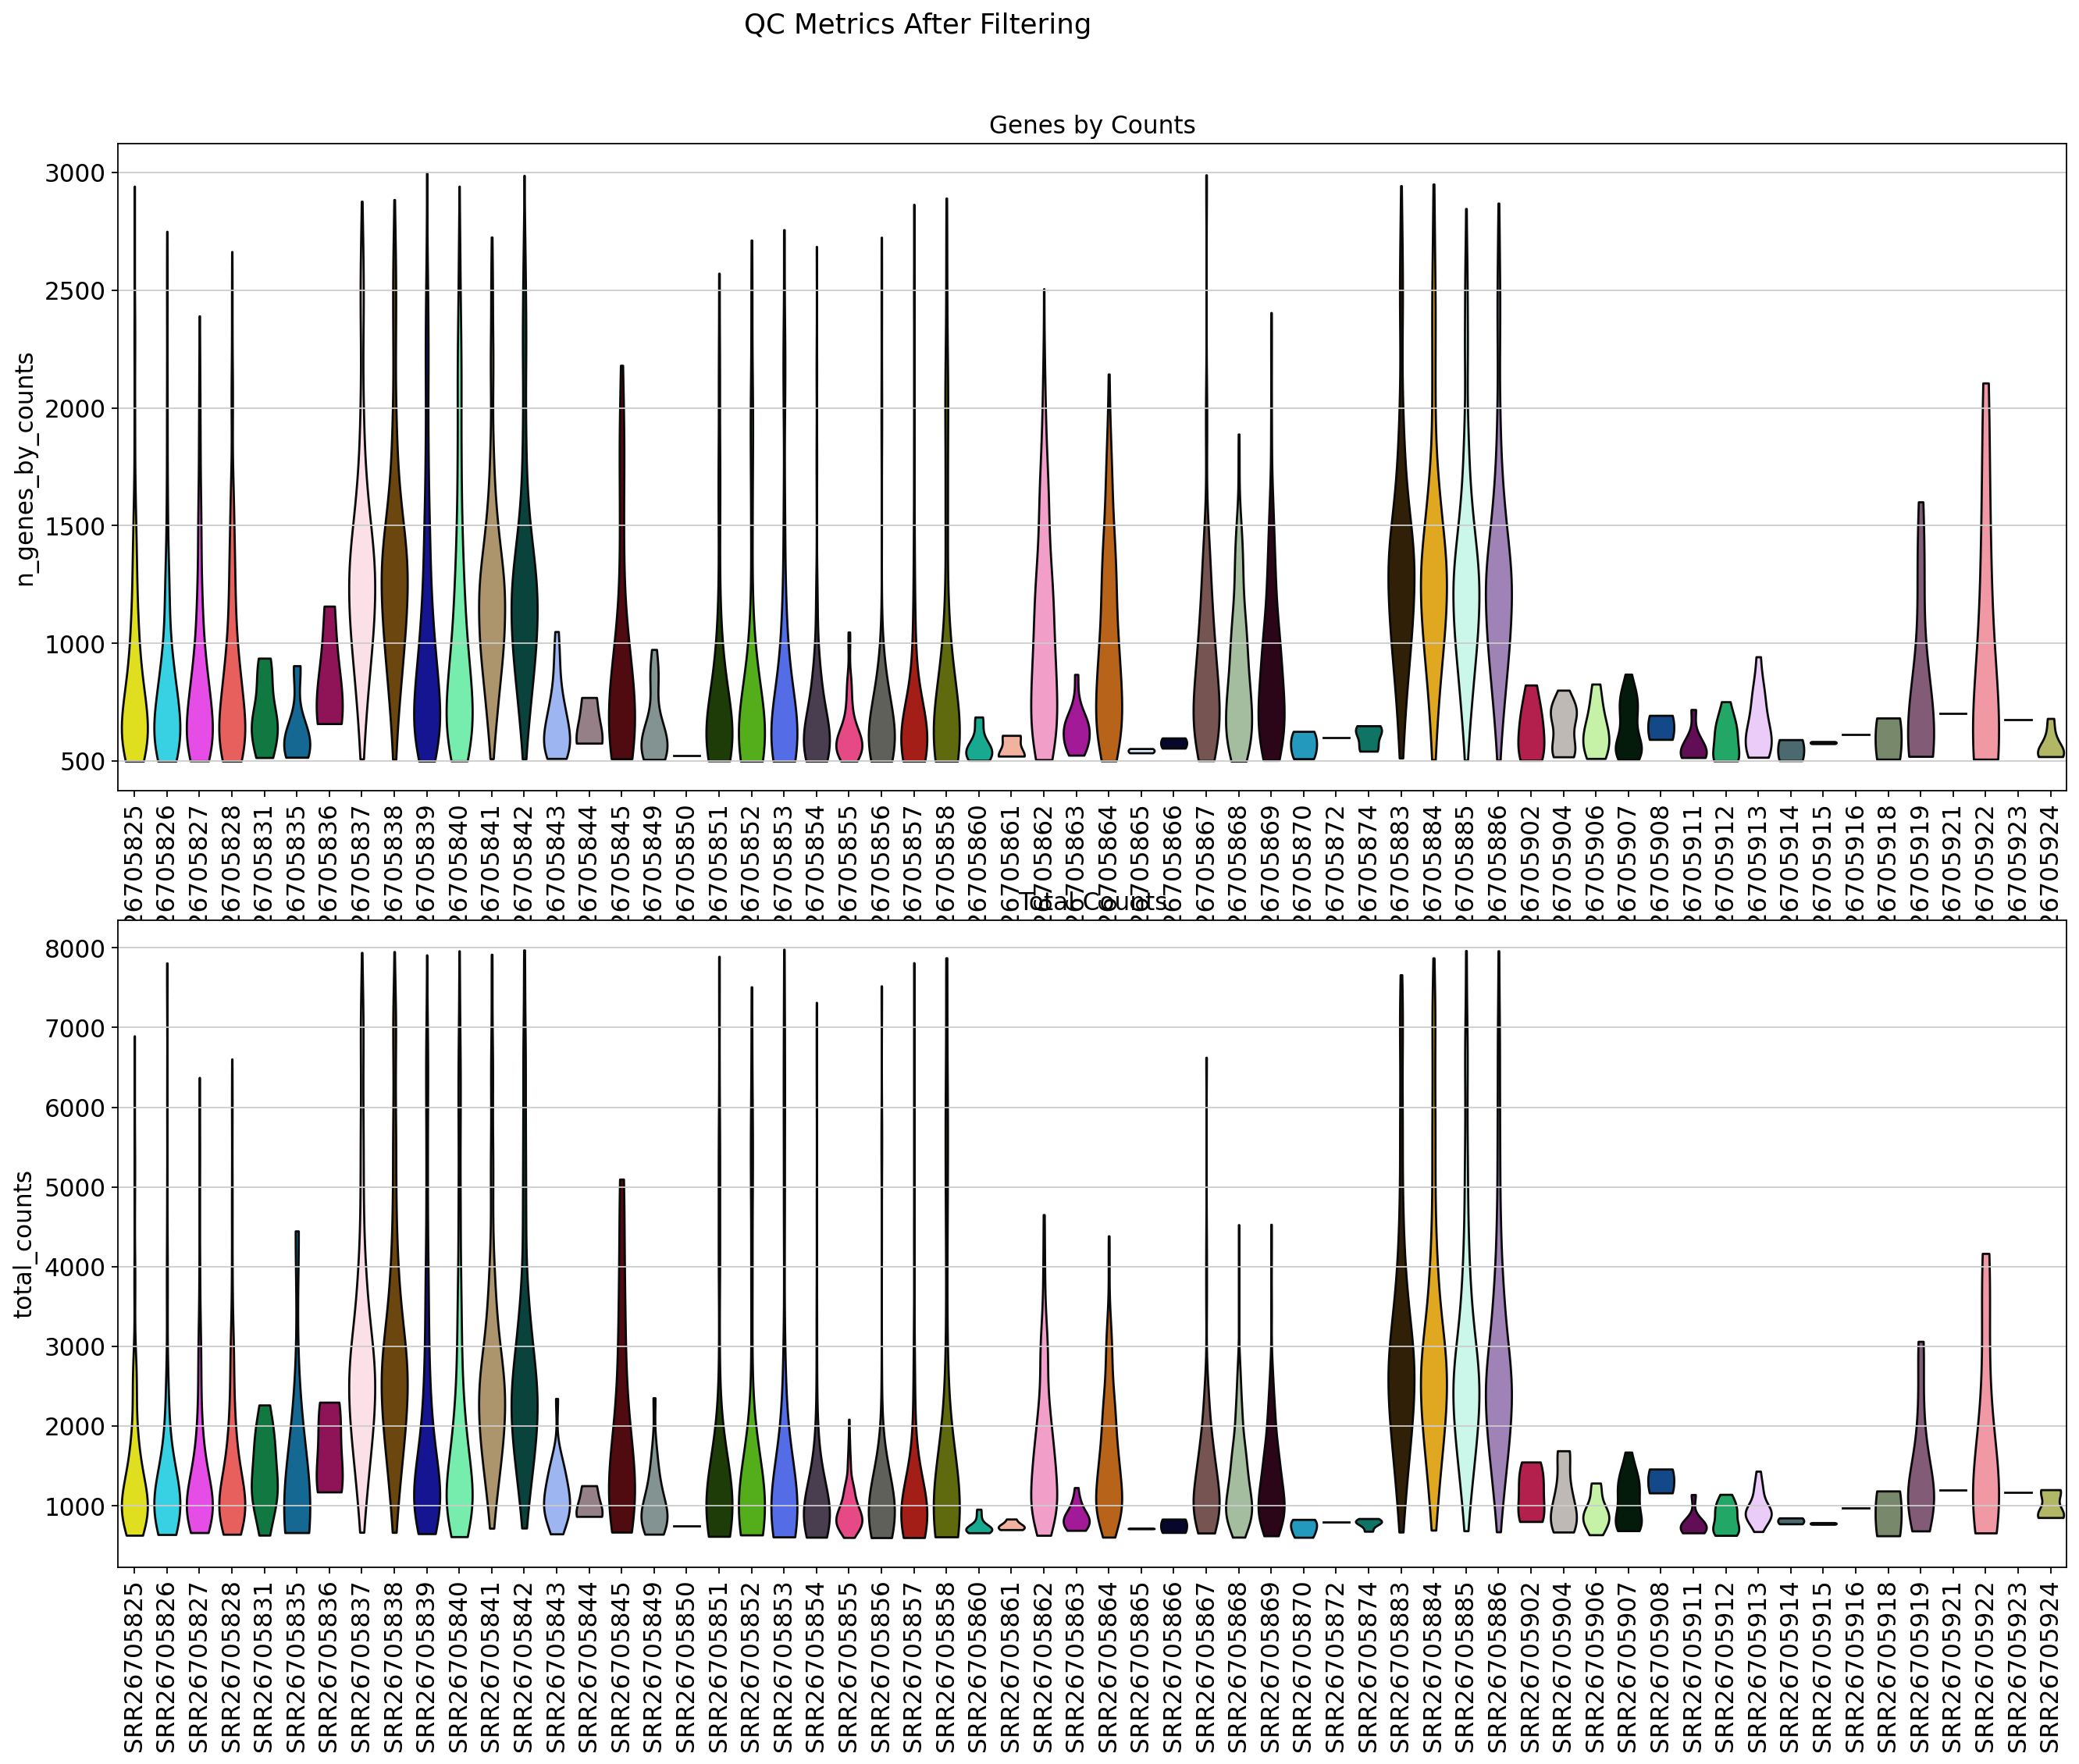

In [111]:
sample_col = 'sample_id'

print("--- Plotting Post-QC Metrics (Grouped by Sample) ---")

# Use subplots to create a single figure with three plots
fig, axes = plt.subplots(2, 1, figsize=(20, 15))
fig.suptitle('QC Metrics After Filtering', fontsize=16)

# Plot 1: n_genes_by_counts
sc.pl.violin(adata_filtered, keys='n_genes_by_counts', groupby=sample_col, rotation=90, stripplot=False, ax=axes[0], show=False)
axes[0].set_title('Genes by Counts')

# Plot 2: total_counts
sc.pl.violin(adata_filtered, keys='total_counts', groupby=sample_col, rotation=90, stripplot=False, ax=axes[1], show=False)
axes[1].set_title('Total Counts')


In [112]:
# --- Configuration ---
sample_col = 'sample_id'   # Column name for your batch/sample
min_median_genes = 500     # Your chosen threshold
# ---------------------

# 1. Calculate Metrics
print(f"--- Starting Sample-Level QC (Threshold: >{min_median_genes} median genes) ---")
sample_metrics = adata.obs.groupby(sample_col)['n_genes_by_counts'].median()

# 2. Identify Samples to Keep and Drop
samples_to_drop = sample_metrics[sample_metrics < min_median_genes].index.tolist()
samples_to_keep = sample_metrics[sample_metrics >= min_median_genes].index.tolist()

# 3. Verbose Reporting
if len(samples_to_drop) > 0:
    print(f"\n⚠️  WARNING: The following {len(samples_to_drop)} samples failed QC:")
    print(f"{'Sample ID':<20} | {'Median Genes':<15} | {'Cells Removed'}")
    print("-" * 55)
    
    total_cells_removed = 0
    for sample in samples_to_drop:
        n_cells = adata.obs[adata.obs[sample_col] == sample].shape[0]
        median_val = sample_metrics[sample]
        print(f"{sample:<20} | {median_val:<15.1f} | {n_cells}")
        total_cells_removed += n_cells
        
    print("-" * 55)
    print(f"Total cells to be removed: {total_cells_removed}")
else:
    print("\n✅ All samples passed Sample-Level QC!")

# 4. Execute Filtering
if len(samples_to_drop) > 0:
    n_before = adata.n_obs
    
    # Filter and Copy (Important for CPU memory release)
    adata = adata[adata.obs[sample_col].isin(samples_to_keep)].copy()
    
    print(f"\nFiltering complete.")
    print(f"Cells before: {n_before}")
    print(f"Cells after:  {adata.n_obs}")
else:
    print("No filtering performed.")

# 5. (Optional) Quick check of remaining samples
print(f"\nRemaining samples: {adata.obs[sample_col].unique().tolist()}")

--- Starting Sample-Level QC (Threshold: >500 median genes) ---

⚠️  WARNING: The following 32 samples failed QC:
Sample ID            | Median Genes    | Cells Removed
-------------------------------------------------------
SRR26705831          | 459.5           | 32
SRR26705835          | 445.0           | 30
SRR26705836          | 420.0           | 15
SRR26705844          | 420.5           | 22
SRR26705850          | 454.0           | 3
SRR26705855          | 484.5           | 244
SRR26705859          | 427.0           | 9
SRR26705860          | 449.5           | 32
SRR26705861          | 439.0           | 27
SRR26705863          | 460.0           | 43
SRR26705865          | 423.0           | 17
SRR26705866          | 439.0           | 15
SRR26705870          | 453.0           | 14
SRR26705871          | 438.0           | 2
SRR26705872          | 480.0           | 3
SRR26705873          | 434.0           | 5
SRR26705874          | 464.0           | 15
SRR26705902          | 443.5   

/storage/homefs/sv24v923/tmp/ipykernel_385716/2317884539.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sample_metrics = adata.obs.groupby(sample_col)['n_genes_by_counts'].median()


In [113]:
adata_filtered.write(OUTPUT_FILE)

normalizing counts per cell
    finished (0:00:02)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    with n_comps=50
    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:07)


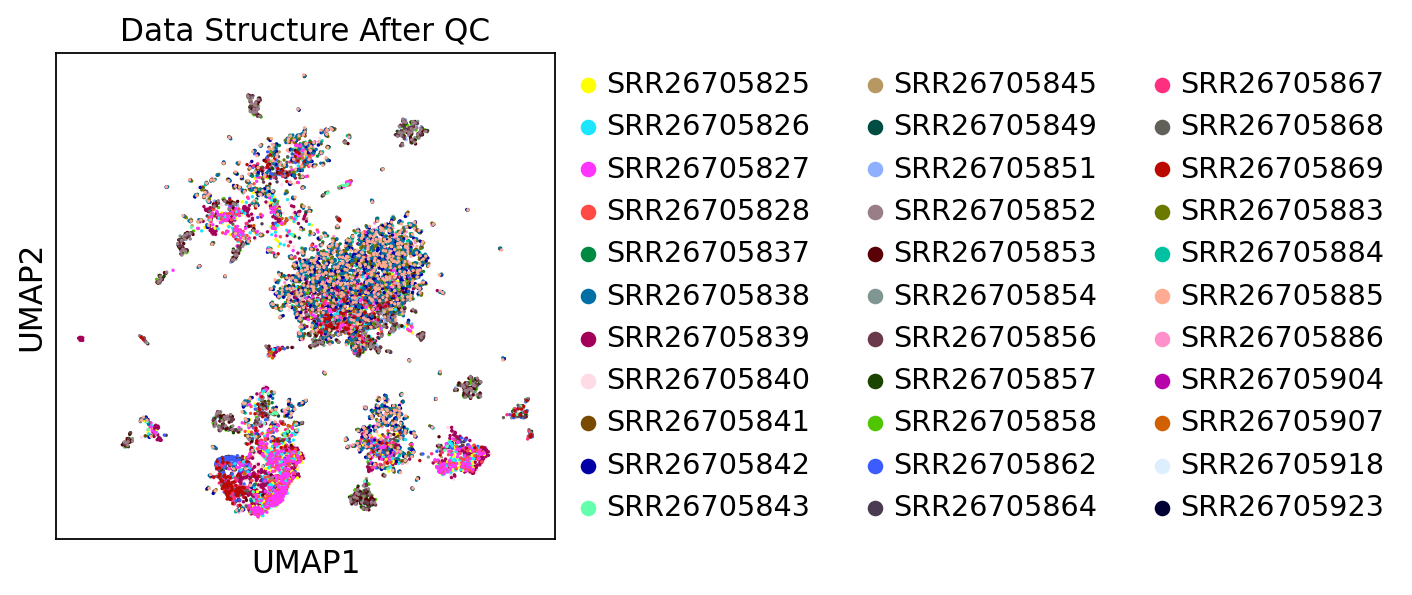

In [83]:
import scanpy as sc

# 1. Normalize and Log-Transform (Essential for valid plots)
# This makes sure a cell with 1000 counts is comparable to one with 5000.
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# 2. Find Variable Genes
# Focus on the top 2,000 genes that actually change (saves CPU time too!)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

# 3. Run PCA (Dimensionality Reduction)
# Compresses the data so the computer can understand the shape
sc.tl.pca(adata, svd_solver='arpack')

# 4. Compute Neighbors & UMAP
# n_neighbors=30 makes the plot look smoother/more connected
sc.pp.neighbors(adata, n_neighbors=30, n_pcs=30)
sc.tl.umap(adata)

# 5. Plot!
# We color by 'sample_id' to see if the samples are mixing well or separated.
sc.pl.umap(adata, color='sample_id', title='Data Structure After QC')